# Convergence analysis using different number of paths - Experiments on one agent using PettingZoo

This notebook explores a scenario where there is one agent in the system and randomly selects both an origin and destination, aiming to learn the optimal route among the available choices. The analysis focuses on evaluating how fast the agent converges, considering different numbers of routes.

## Experiment Summary

- **Network Architecture:** Utilization of the Csomor network.
- **Agents:** Altruistic.
- **Reinforcement Learning Algorithm:** Proximal Policy Optimization (PPO)

    - **PPO Hyperparameters:**
        - *Gamma:* 0.9
        - *Learning Rate:* 1e-3
        - *Timesteps:* 1000


### 3 paths to choose from

In [1]:
from environment import TrafficEnvironment
from keychain import Keychain as kc
import os
from stable_baselines3 import DQN
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3 import PPO
import supersuit as ss
from Sumo_controller import Sumo

from utilities import confirm_env_variable
from utilities import get_params
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

In [2]:
confirm_env_variable(kc.SUMO_HOME, append="tools")
params = get_params(kc.PARAMS_PATH)

[CONFIRMED] Environment variable exists: SUMO_HOME
[SUCCESS] Added module directory: C:\Program Files (x86)\Eclipse\Sumo\tools


In [3]:
Sumo_sim=Sumo(params)
Sumo_sim.Sumo_start()

In [4]:
env = TrafficEnvironment(params[kc.ENVIRONMENT_PARAMETERS], params[kc.SIMULATION_PARAMETERS], params[kc.AGENTS_GENERATION_PARAMETERS])

[SUCCESS] Generated & saved 12 paths to: paths.csv
[SUCCESS] Environment initiated!
[INFO] Free-flow times:  {(0, 0): [5.617165975566803, 45.08917067806191, 109.42695563466584], (0, 1): [51.03261476439725, 139.03180179671705, 375.1153910024779], (1, 0): [43.93199829112916, 4.59822842086661, 13.62798048647607], (1, 1): [1254.5593759588041, 2719.8132149004878, 87.82011083088526]}
[SUCCESS] Free flow times calculated!
[SUCCESS]: The vehicle will travel from origin  [1]  to destination. [0]  This path has free flow travel time:  [43.93199829112916, 4.59822842086661, 13.62798048647607]


In [5]:
env.reset()
env.reward_table = []

In [6]:
env = ss.pettingzoo_env_to_vec_env_v1(env)
env = ss.concat_vec_envs_v1(env, 1, num_cpus=2, base_class="stable_baselines3")

In [7]:
tuned_params = {
        "gamma": 0.9,
        "learning_rate": 1e-3,
    }

model = PPO(
    "MlpPolicy",
    env,
    verbose = 0,
    n_steps = 10,
    batch_size=10,
    **tuned_params
)

In [8]:
model.learn(total_timesteps=1000)

Reward table is:  [-56.61666666666667, -16.55, -56.61666666666667, -56.61666666666667, -16.55, -5.8, -56.61666666666667, -56.61666666666667, -16.55, -16.55, -16.55, -56.61666666666667, -16.55, -16.55, -16.55, -5.8, -5.8, -5.8, -16.55, -56.61666666666667, -16.55, -5.8, -16.55, -56.61666666666667, -5.8, -16.55, -5.8, -5.8, -16.55, -16.55, -16.55, -5.8, -16.55, -5.8, -16.55, -5.8, -16.55, -16.55, -16.55, -5.8, -56.61666666666667, -5.8, -16.55, -5.8, -5.8, -56.61666666666667, -56.61666666666667, -56.61666666666667, -5.8, -5.8, -5.8, -16.55, -5.8, -5.8, -5.8, -5.8, -5.8, -5.8, -5.8, -5.8, -5.8, -5.8, -16.55, -5.8, -5.8, -5.8, -5.8, -16.55, -56.61666666666667, -5.8, -16.55, -5.8, -5.8, -5.8, -5.8, -5.8, -5.8, -5.8, -5.8, -5.8, -56.61666666666667, -5.8, -56.61666666666667, -5.8, -5.8, -5.8, -5.8, -5.8, -5.8, -5.8, -5.8, -5.8, -5.8, -5.8, -5.8, -5.8, -5.8, -5.8, -5.8, -5.8, -5.8, -5.8, -5.8, -5.8, -5.8, -5.8, -5.8, -5.8, -5.8, -5.8, -5.8, -5.8, -5.8, -5.8, -5.8, -5.8, -16.55, -5.8, -5.8, -5.8,

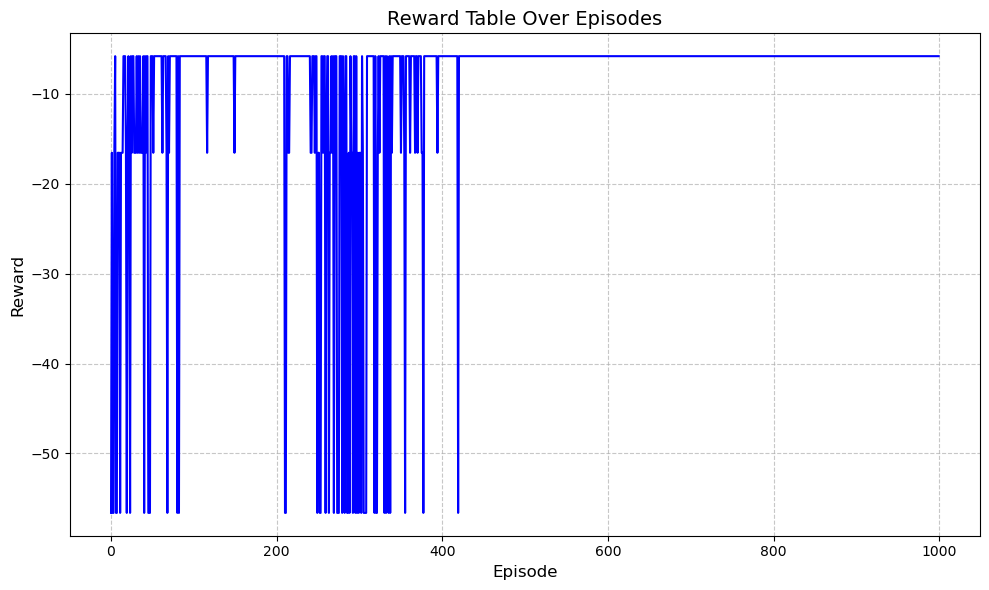

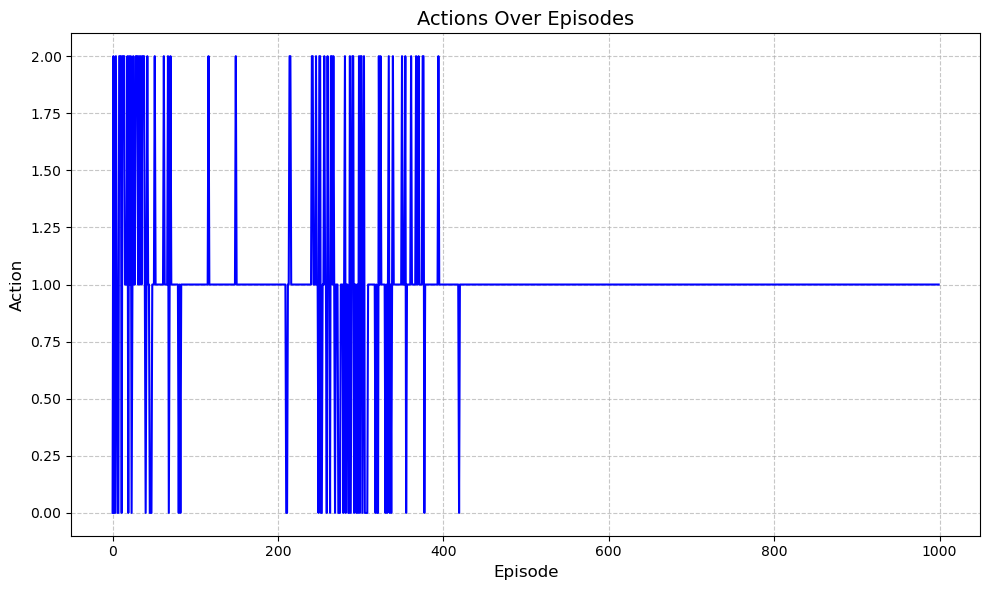

In [9]:
env.close()

### 5 paths to choose from

In [4]:
env = TrafficEnvironment(params[kc.ENVIRONMENT_PARAMETERS], params[kc.SIMULATION_PARAMETERS], params[kc.AGENTS_GENERATION_PARAMETERS])

[SUCCESS] Generated & saved 20 paths to: paths.csv
[SUCCESS] Environment initiated!
[INFO] Free-flow times:  {(0, 0): [99.52313151579803, 738.1681223654563, 67.75759435664993, 254.7980625101379, 50.63343101289922], (0, 1): [124.64048548144984, 99.54601023600766, 331.4658934828206, 112.7828748634084, 94.8224258877251], (1, 0): [10.450086485278058, 425.2665515862779, 27.43116081951539, 241.95718860697806, 198.57759902788493], (1, 1): [85.87998865222586, 2062.390986387125, 122.15831014784956, 2001.8203472258192, 216.08241938214135]}
[SUCCESS] Free flow times calculated!
Agent 0 has origin 1 and destination 1.


In [5]:
env.reset()
env.reward_table = []
env.actions = []

In [6]:
env = ss.pettingzoo_env_to_vec_env_v1(env)
env = ss.concat_vec_envs_v1(env, 1, num_cpus=2, base_class="stable_baselines3")

In [7]:
tuned_params = {
        "gamma": 0.9,
        "learning_rate": 1e-3,
    }

model = PPO(
    "MlpPolicy",
    env,
    verbose = 1,
    n_steps = 10,
    batch_size=10,
    **tuned_params
)

Using cpu device


In [8]:
model.learn(total_timesteps=1000) ##need to put Discrete(5) in the environment

----------------------------
| time/              |     |
|    fps             | 0   |
|    iterations      | 1   |
|    time_elapsed    | 184 |
|    total_timesteps | 10  |
----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 0            |
|    iterations           | 2            |
|    time_elapsed         | 415          |
|    total_timesteps      | 20           |
| train/                  |              |
|    approx_kl            | 0.0007745445 |
|    clip_fraction        | 0            |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.61        |
|    explained_variance   | -1.19e-07    |
|    learning_rate        | 0.001        |
|    loss                 | 9.71e+05     |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.0162      |
|    value_loss           | 1.94e+06     |
------------------------------------------
-----------------------

Reward table is:  [-277.73333333333335, -110.65, -2561.65, -110.65, -277.73333333333335, -2453.85, -110.65, -277.73333333333335, -2561.65, -110.65, -2561.65, -110.65, -2453.85, -277.73333333333335, -277.73333333333335, -155.31666666666666, -2453.85, -110.65, -277.73333333333335, -277.73333333333335, -2453.85, -110.65, -2453.85, -2453.85, -155.31666666666666, -110.65, -2453.85, -277.73333333333335, -155.31666666666666, -2561.65, -110.65, -110.65, -155.31666666666666, -2453.85, -277.73333333333335, -2453.85, -155.31666666666666, -155.31666666666666, -155.31666666666666, -155.31666666666666, -155.31666666666666, -110.65, -110.65, -110.65, -110.65, -155.31666666666666, -277.73333333333335, -2561.65, -110.65, -155.31666666666666, -2453.85, -155.31666666666666, -110.65, -2453.85, -277.73333333333335, -2453.85, -2453.85, -110.65, -2453.85, -2561.65, -277.73333333333335, -277.73333333333335, -2561.65, -277.73333333333335, -155.31666666666666, -2561.65, -155.31666666666666, -155.31666666666666,

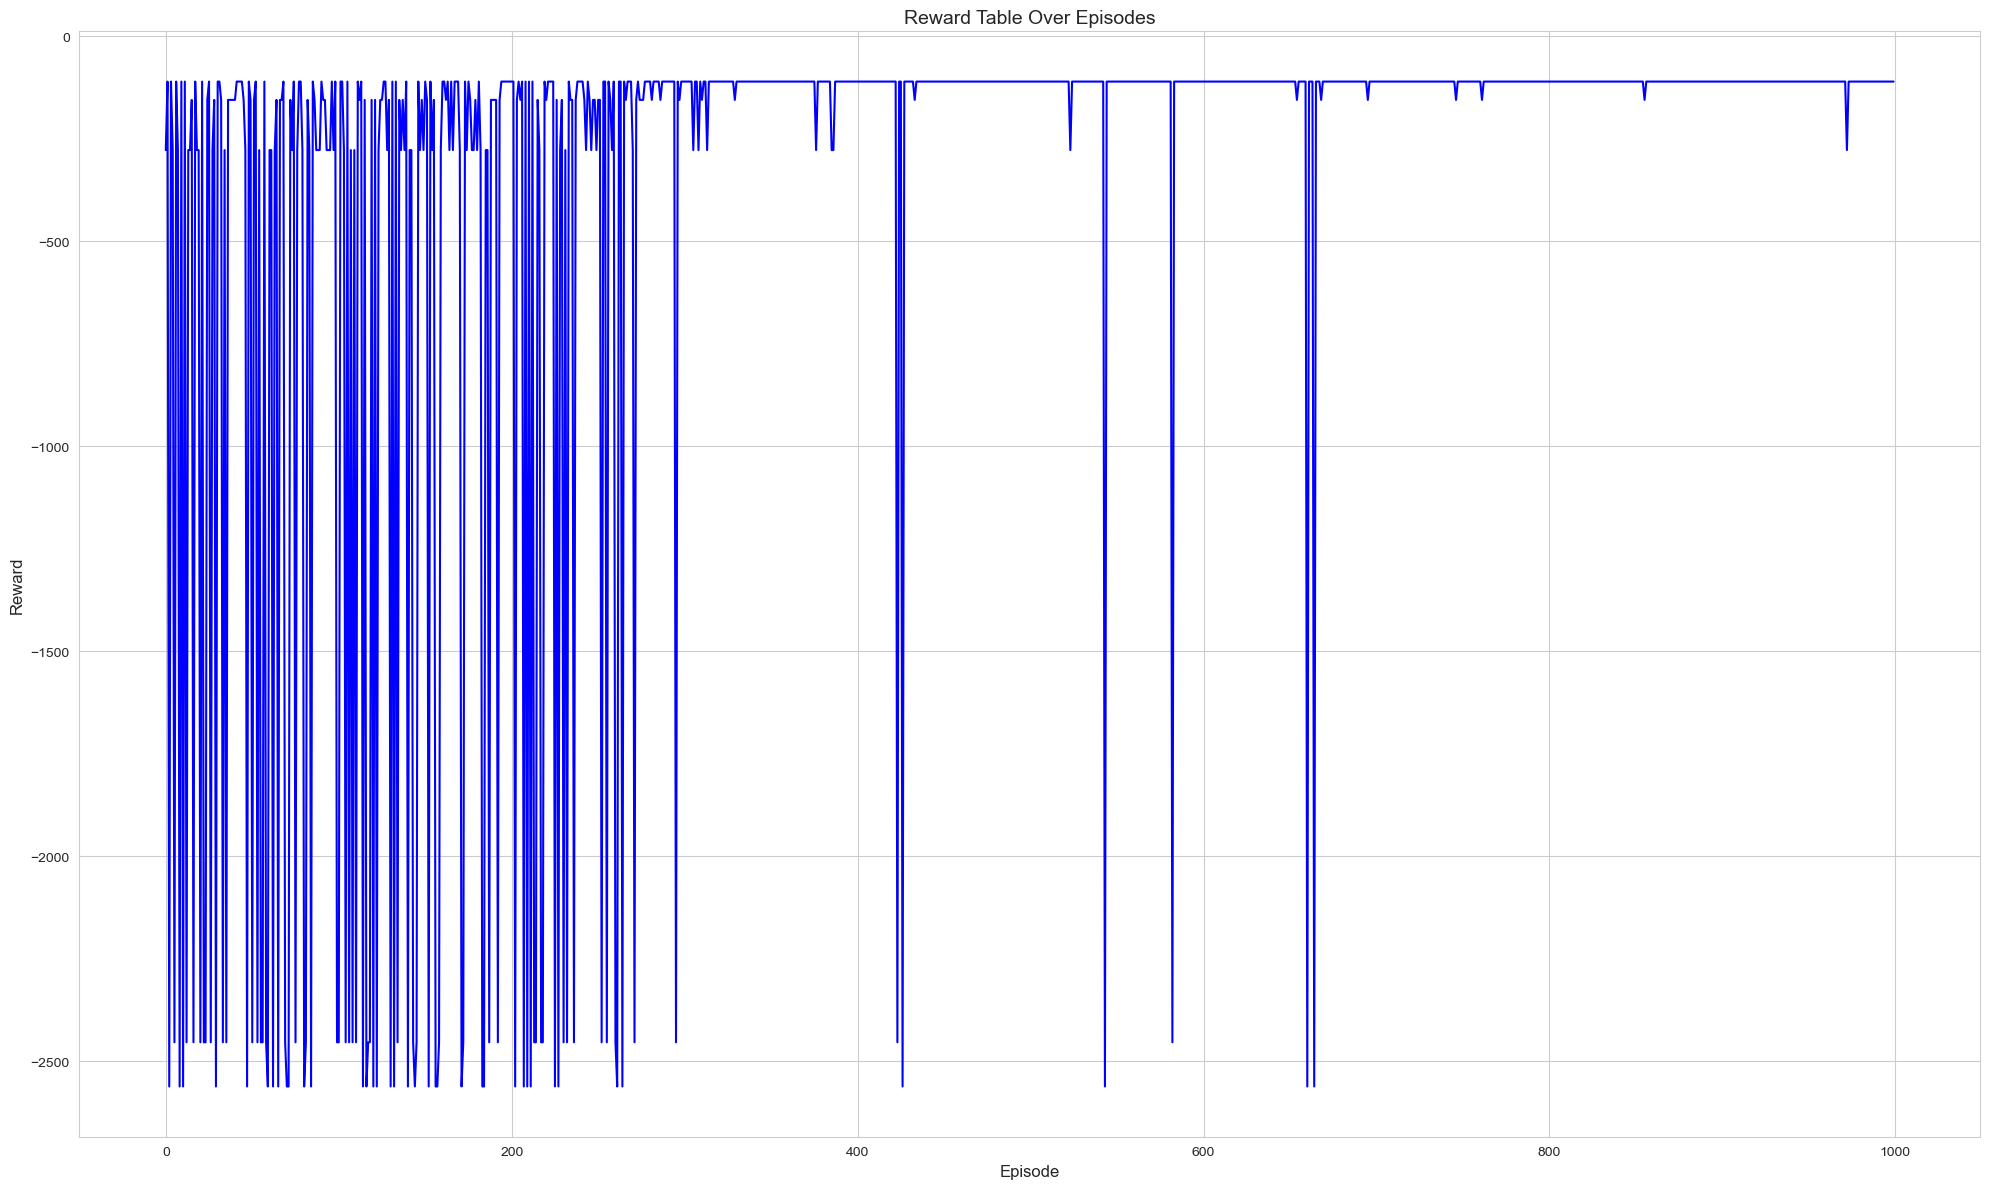

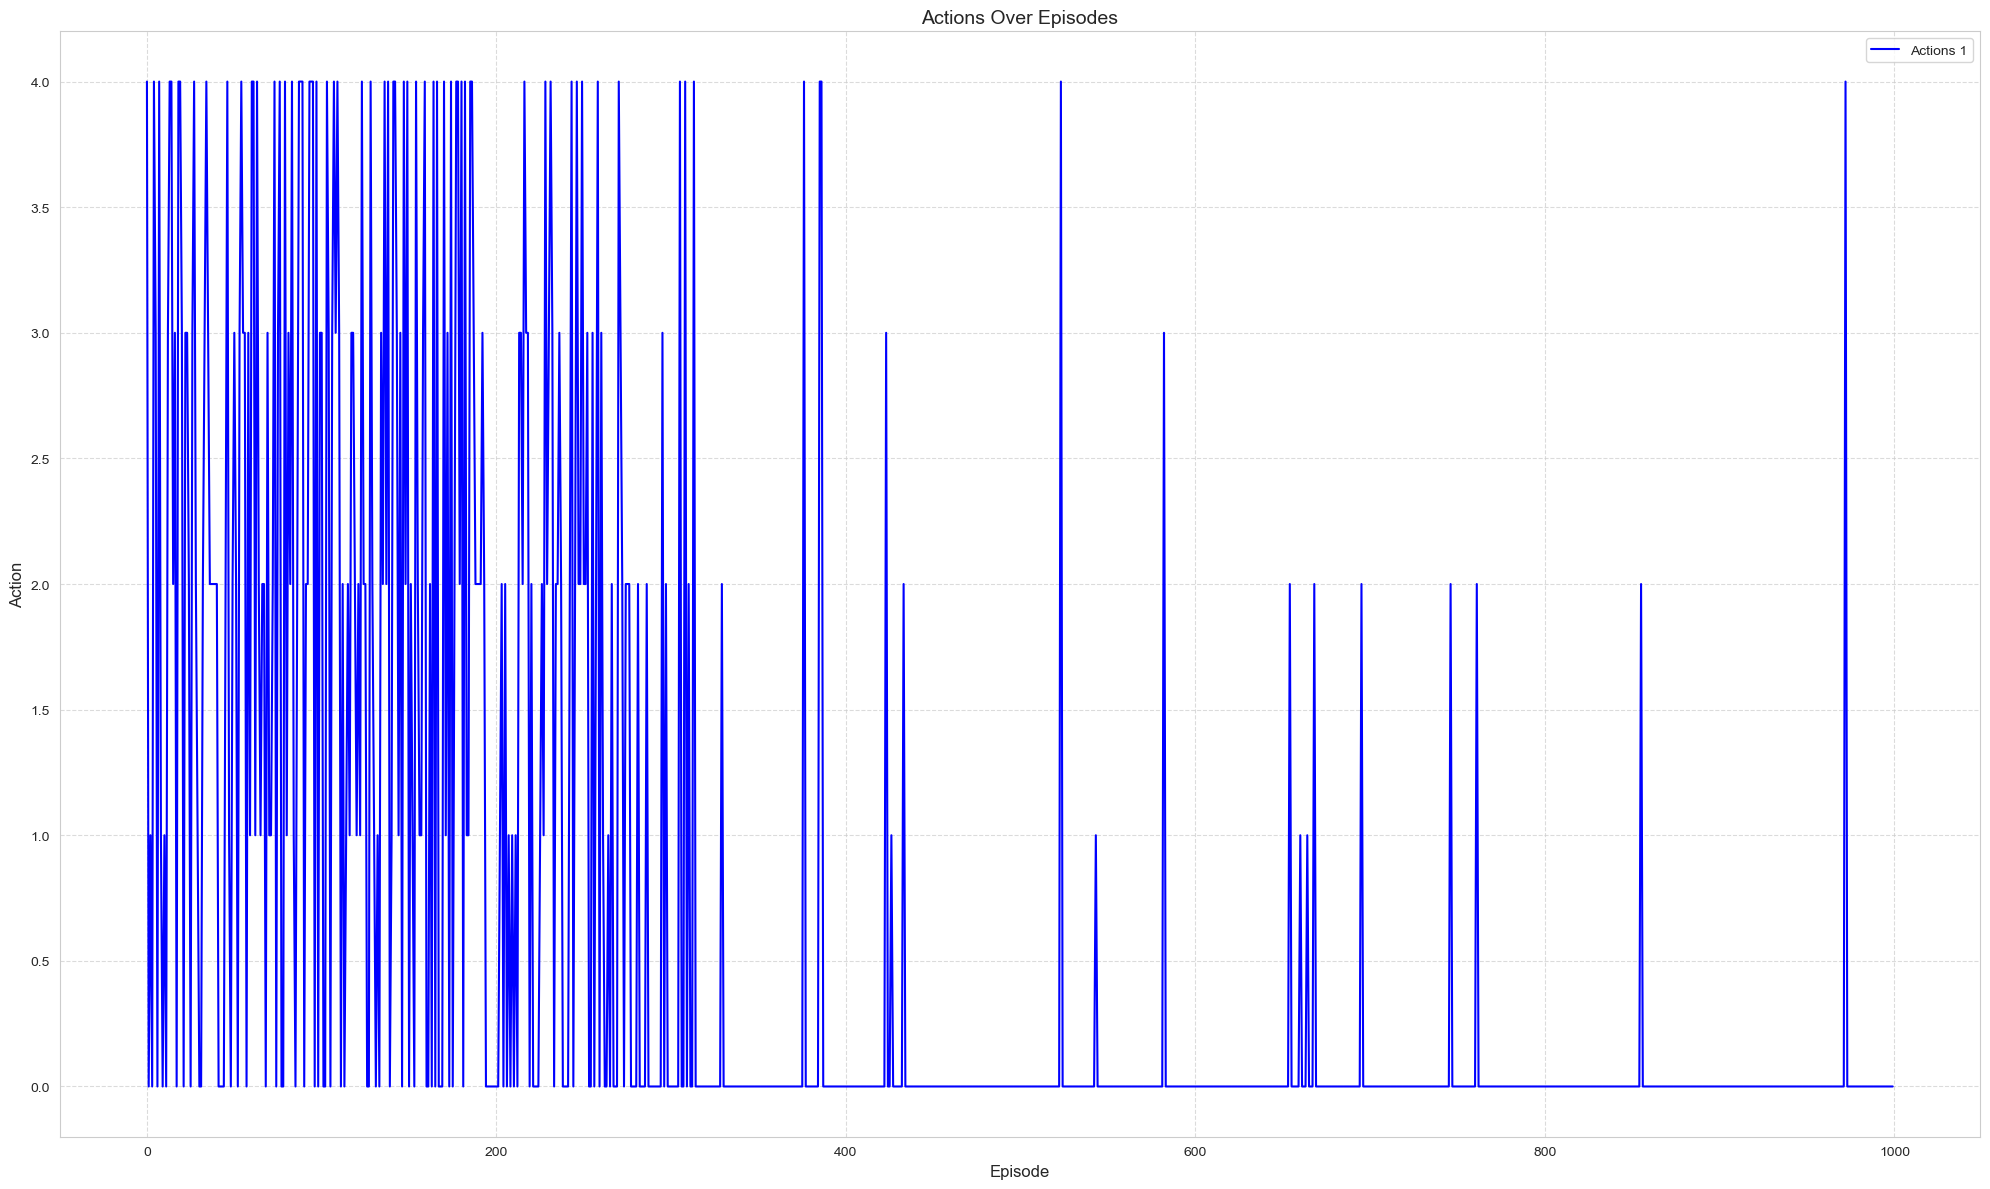

In [9]:
env.close()

## Conclusions

In scenarios where agents have a choice between three paths, convergence appears to occur more rapidly compared to scenarios with five available paths. This discrepancy can be attributed to the relatively shorter free flow travel times associated with the chosen paths in the three-path scenario. Conversely, in the five-path scenario, free flow travel times are considerably longer, up to 100 times in some instances.